In [1]:
# Core libraries
#%pip install -U pandas numpy scikit-learn umap-learn hdbscan plotly

# BERTopic + embeddings
#%pip install -U bertopic sentence-transformers

### Imports and helper functions


In [ ]:
import re
import pandas as pd

from pathlib import Path
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS
from umap import UMAP
from hdbscan import HDBSCAN

from collections import Counter
from sklearn.cluster import KMeans
from sklearn.preprocessing import normalize
import matplotlib.pyplot as plt
import pandas as pd
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import normalize
from collections import Counter


In [3]:
try:
    from bertopic.representation import KeyBERTInspired, MaximalMarginalRelevance
    HAS_REPR = True
except Exception:
    HAS_REPR = False

# c-TF-IDF transformer is optional
try:
    from bertopic.vectorizers import ClassTfidfTransformer
    HAS_CTFIDF = True
except Exception:
    HAS_CTFIDF = False


def clean_text(x) -> str:
    """Basic cleanup: normalize whitespace, remove newlines."""
    if pd.isna(x):
        return ""
    s = str(x).replace("\r", " ").replace("\n", " ")
    s = re.sub(r"\s+", " ", s).strip()
    return s


def build_document(row: pd.Series) -> str:
    """Build one document (string) from Title + Abstract + AuthorKeywords."""
    title = clean_text(row.get("Title", ""))
    abstract = clean_text(row.get("Abstract", ""))
    keywords = clean_text(row.get("AuthorKeywords", ""))
    parts = [p for p in [title, abstract, keywords] if p]
    return " . ".join(parts)


def slugify(s: str) -> str:
    """Turn a label into a URL/file safe slug."""
    s = s.lower()
    s = re.sub(r"[^a-z0-9]+", "-", s).strip("-")
    return s


### Configuration

Set paths and BERTopic hyperparameters.

- `nr_topics`: force the model down to a target number of clusters/topics (optional).
- `min_topic_size`: minimum cluster size (higher = fewer, larger clusters).


In [4]:
# ---- Paths ----
INPUT_CSV = "../data/processed/dataset_clean.csv"   
OUTPUT_DIR = "../data/processed"

# ---- Model settings ----
NR_TOPICS = 30          # set to None to skip topic reduction: with None, original number of topics is used 52
MIN_TOPIC_SIZE = 15
LANGUAGE = "english"

# ---- Filtering settings ----
MIN_DOC_LEN = 30        # drop docs shorter than this (helps reduce -1 outliers)

# Make sure output dir exists
out_dir = Path(OUTPUT_DIR)
out_dir.mkdir(parents=True, exist_ok=True)

print("Output folder:", out_dir.resolve())


Output folder: /Users/irynasavchuk/Desktop/DATAVIZ_PROJECT/DV/dv_repo/data/processed


### Load dataset and build documents
- read the CSV
- optionally drop duplicate DOIs
- build `docs` (one string per paper)
- drop empty/too-short documents


In [5]:
df = pd.read_csv(INPUT_CSV, encoding="utf-8", encoding_errors="replace")
print("Rows loaded:", len(df))
print("Columns:", list(df.columns))

# Optional: remove duplicates by DOI if present
if "DOI" in df.columns:
    before = len(df)
    df = df.drop_duplicates(subset=["DOI"], keep="first").reset_index(drop=True)
    print(f"Dropped {before - len(df)} duplicate DOIs")

# Build documents for topic modeling
docs = df.apply(build_document, axis=1).tolist()

# Drop empty/too-short docs (these inflate the -1 outlier topic)
keep = [i for i, d in enumerate(docs) if len(d) >= MIN_DOC_LEN]
df = df.iloc[keep].reset_index(drop=True)
docs = [docs[i] for i in keep]

print("Rows after filtering:", len(df))


Rows loaded: 3530
Columns: ['Conference', 'Year', 'Title', 'DOI', 'PaperType', 'Abstract', 'AuthorNames-Deduped', 'AuthorAffiliation', 'InternalReferences', 'AuthorKeywords', 'AminerCitationCount', 'CitationCount_CrossRef', 'PubsCited_CrossRef', 'Downloads_Xplore', 'Award', 'GraphicsReplicabilityStamp', 'MacroId', 'Cluster', 'MacroCategory', 'MacroSlug', 'ClusterShort', 'ClusterSlug', 'ClusterFileSlug']
Dropped 0 duplicate DOIs
Rows after filtering: 3530


### Build BERTopic model

Key choices:
- **Embeddings**: `all-mpnet-base-v2` (higher quality than MiniLM; slower but usually better topics)
- **Stopwords**: English + domain-specific stopwords (improves interpretability)
- **UMAP**: reduce embedding dimensionality before clustering
- **HDBSCAN**: density-based clustering; creates an outlier topic `-1`
- Optional:
  - improved c-TF-IDF (BM25 weighting)
  - improved representation labels (KeyBERT-inspired + MMR)


In [6]:
# Better embeddings (more accurate than MiniLM; slower but worth it)
# If speed matters, switch to: SentenceTransformer("all-MiniLM-L6-v2")
embedding_model = SentenceTransformer("all-mpnet-base-v2")

# Domain stopwords to improve interpretability
domain_stop = {
    "visualization", "visualizations", "visualize", "visualizing", "visual",
    "analytics", "analysis", "approach", "method", "methods", "technique",
    "system", "framework", "model", "models", "data", "dataset", "datasets",
    "interactive", "interaction", "user", "users", "paper", "results",
    "using", "based", "task", "tasks", "provide", "propose", "present",
}
stop_words = set(ENGLISH_STOP_WORDS).union(domain_stop)

vectorizer_model = CountVectorizer(
    stop_words=list(stop_words) if LANGUAGE == "english" else None,
    ngram_range=(1, 3),
    min_df=3,
    max_df=0.6,
)

# Optional: better c-TF-IDF weighting
ctfidf_model = None
if HAS_CTFIDF:
    ctfidf_model = ClassTfidfTransformer(bm25_weighting=True, reduce_frequent_words=True)

# Better manifold + clustering for text corpora
umap_model = UMAP(
    n_neighbors=25,
    n_components=5,
    min_dist=0.0,
    metric="cosine",
    random_state=42,
)

hdbscan_model = HDBSCAN(
    min_cluster_size=MIN_TOPIC_SIZE,
    min_samples=max(2, MIN_TOPIC_SIZE // 3),
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True,
)

# Topic representation / labeling (optional)
representation_model = None
if HAS_REPR:
    representation_model = [
        KeyBERTInspired(),
        MaximalMarginalRelevance(diversity=0.4),
    ]

topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    ctfidf_model=ctfidf_model,
    representation_model=representation_model,
    min_topic_size=MIN_TOPIC_SIZE,
    calculate_probabilities=True,
    language=LANGUAGE,
    verbose=True,
)


### Fit BERTopic and improve outliers

- fit the model
- optionally **re-assign outliers** (topic `-1`) into existing topics
- optionally reduce to a target number of topics (`NR_TOPICS`)


In [7]:
topics, probs = topic_model.fit_transform(docs)

# Re-assign many -1 outliers into existing topics (often a big improvement)
try:
    topics = topic_model.reduce_outliers(docs, topics, probabilities=probs, threshold=0.05)
    topic_model.update_topics(
        docs,
        topics=topics,
        vectorizer_model=vectorizer_model,
        representation_model=representation_model
    )
    print("Outlier reduction applied.")
except Exception as e:
    print("Outlier reduction skipped:", e)

# Optional: force a target number of topics after fitting
if NR_TOPICS is not None:
    topic_model.reduce_topics(docs, nr_topics=NR_TOPICS)
    topics = topic_model.topics_

print("Unique topics (including -1):", len(set(topics)))


2026-01-09 10:38:22,344 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/111 [00:00<?, ?it/s]

2026-01-09 10:41:40,788 - BERTopic - Embedding - Completed ✓
2026-01-09 10:41:40,792 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
2026-01-09 10:41:59,950 - BERTopic - Dimensionality - Completed ✓
2026-01-09 10:41:59,951 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-01-09 10:42:00,287 - BERTopic - Cluster - Completed ✓
2026-01-09 10:42:00,297 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-01-09 10:42:32,973 - BERTopic - Representation - Completed ✓
100%|██████████| 1/1 [00:00<00:00,  1.00it/s]
2026-01-09 10:42:34,494 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings 

Outlier reduction applied.


2026-01-09 10:43:31,309 - BERTopic - Representation - Completed ✓
2026-01-09 10:43:31,494 - BERTopic - Topic reduction - Reduced number of topics from 55 to 29


Unique topics (including -1): 29


### Create human-readable cluster names (topic labels)

We try BERTopic's `generate_topic_labels`. 


In [8]:
topic_info = topic_model.get_topic_info()

# Generate readable labels (version-dependent)
try:
    labels = topic_model.generate_topic_labels(nr_words=4, topic_prefix=False, separator=" • ")
    try:
        topic_model.set_topic_labels(labels)  # optional (version-dependent)
    except Exception:
        pass
except Exception:
    labels = None

# Build a label map
if labels is not None:
    label_map = dict(zip(topic_info["Topic"].tolist(), labels))
else:
    label_map = {}
    for t in topic_info["Topic"].tolist():
        if t == -1:
            label_map[t] = "Other / Mixed"
            continue
        words = [w for (w, _) in topic_model.get_topic(t)[:6]]
        label_map[t] = " • ".join(words[:4])

topic_info["Category"] = topic_info["Topic"].map(label_map)
topic_info.head(10)


,Topic,Count,Name,Representation,Representative_Docs,Category
0,0,729,0_meshes_triangulation_surface reconstruction_...,"[meshes, triangulation, surface reconstruction...",[New quadric metric for simplifying meshes wit...,meshes • triangulation • surface reconstructio...
1,1,366,1_flow field_flow fields_computational fluid d...,"[flow field, flow fields, computational fluid ...",[UFAT-a particle tracer for time-dependent flo...,flow field • flow fields • computational fluid...
2,2,286,2_causality_causal_chart_inference,"[causality, causal, chart, inference, associat...",[The Visual Causality Analyst: An Interactive ...,causality • causal • chart • inference
3,3,186,3_parallel coordinate plots_coordinate plots_p...,"[parallel coordinate plots, coordinate plots, ...",[Shape-preserving Star Coordinates . Dimension...,parallel coordinate plots • coordinate plots •...
4,4,139,4_deep neural networks_deep learning_deep neur...,"[deep neural networks, deep learning, deep neu...",[Summit: Scaling Deep Learning Interpretabilit...,deep neural networks • deep learning • deep ne...
5,5,137,5_projector_calibration_camera_cameras,"[projector, calibration, camera, cameras, alig...",[Auto-Calibration of Multi-Projector Displays ...,projector • calibration • camera • cameras
6,6,134,6_treemaps_treemap_volume exploration_volume i...,"[treemaps, treemap, volume exploration, volume...",[Perceptual Guidelines for Creating Rectangula...,treemaps • treemap • volume exploration • volu...
7,7,123,7_unstructured text_topic modeling_text mining...,"[unstructured text, topic modeling, text minin...",[Elastic Documents: Coupling Text and Tables t...,unstructured text • topic modeling • text mini...
8,8,114,8_simulation ensembles_parameter space explora...,"[simulation ensembles, parameter space explora...",[Effective Visualization of Temporal Ensembles...,simulation ensembles • parameter space explora...
9,9,113,9_direct volume rendering_ray tracing_unstruct...,"[direct volume rendering, ray tracing, unstruc...",[Fast Perspective Volume Rendering with Splatt...,direct volume rendering • ray tracing • unstru...


### Add cluster number + cluster name back into the original dataset

This creates a new CSV that contains your original columns plus:

- `Cluster` (topic number)
- `ClusterName` (human-readable topic label)
- `ClusterSlug` (slugified label)

This matches your request: **"add in this dataset only number of cluster"** (and we also add the name).


In [9]:
# Document-level outputs from BERTopic
doc_info = topic_model.get_document_info(docs, df=df)

# Add friendly label columns
doc_info["ClusterName"] = doc_info["Topic"].map(label_map)
doc_info["ClusterSlug"] = doc_info["ClusterName"].map(slugify)

# Create a clean dataset copy with cluster columns
df_with_clusters = df.copy()
df_with_clusters["Cluster"] = doc_info["Topic"].values
df_with_clusters["ClusterName"] = doc_info["ClusterName"].values
df_with_clusters["ClusterSlug"] = doc_info["ClusterSlug"].values

### Group ~30 clusters into 12 *macro categories* 


Macro categorization complete using Agglomerative Clustering.
Top macro sizes:
                                            MacroName  Count
2   Macro 2: meshes • triangulation • surface reco...   1306
4   Macro 4: flow field • flow fields • computatio...    509
3   Macro 3: infographics • parallel coordinate pl...    387
1   Macro 1: direct volume rendering • treemaps • ...    335
0   Macro 0: authoring • deep neural networks • de...    302
10  Macro 10: projector • calibration • camera • c...    188
5   Macro 5: geophysical • geological • topography...    165
8   Macro 8: topological features • contour trees ...    111
9   Macro 9: interface exploration • database mana...     71
7   Macro 7: volume illumination • volumetric shad...     57
11  Macro 11: wavelet • wavelets • multiresolution...     52
6   Macro 6: anomaly detection • network security ...     47

Detailed topic-macro mapping saved to: ../data/processed/topic_macro_mapping.csv
    topic_id                                  

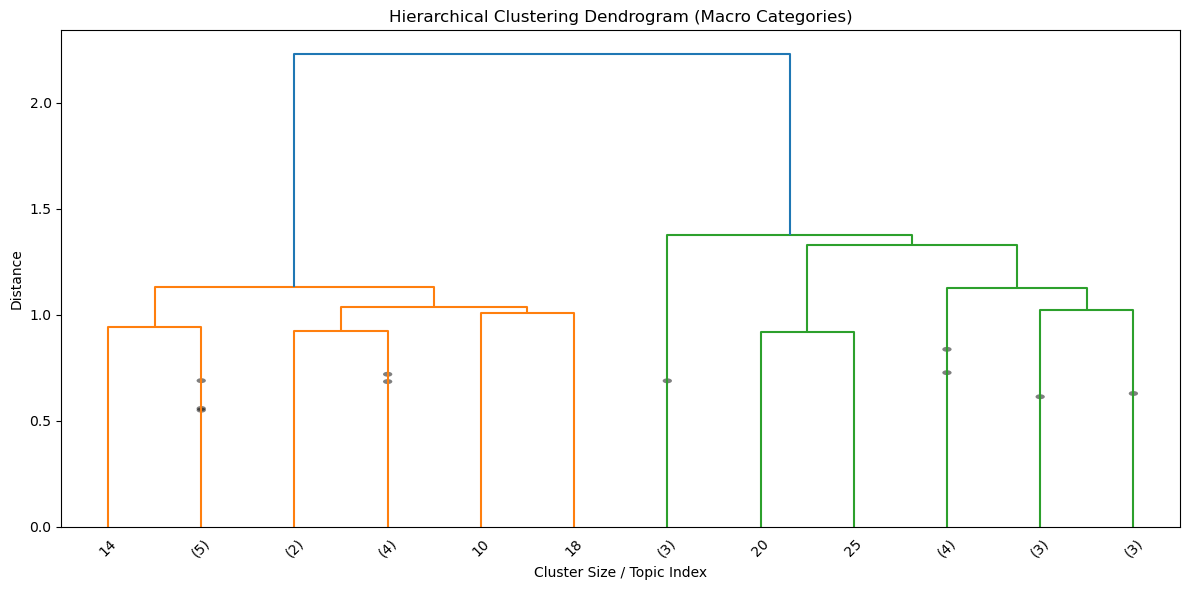

In [12]:
# --- Configuration ---
# Number of Macro Categories to create.
# I increased this to 12 to handle large clusters better. Try 15 if Macro 2 is still too big.
N_MACRO = 12  

# --- Step 1: Prepare Topic Data ---
# We only want to cluster "real" topics, ignoring the -1 outlier topic
topic_ids = topic_info.loc[topic_info.Topic != -1, "Topic"].astype(int).tolist()

# Extract the centroid embeddings for these topics
topic_emb = topic_model.topic_embeddings_[topic_ids]

# Normalize embeddings. 
# Agglomerative 'ward' linkage uses Euclidean distance. 
# Normalizing vectors makes Euclidean distance behave like Cosine similarity.
topic_emb_norm = normalize(topic_emb)

# --- Step 2: Agglomerative Clustering (The Fix) ---
# We use 'ward' linkage because it minimizes variance within clusters.
# It is generally better at creating cohesive hierarchies than K-Means for text topics.
cluster_model = AgglomerativeClustering(n_clusters=N_MACRO, linkage='ward')
macro_ids = cluster_model.fit_predict(topic_emb_norm)

# Create a dictionary to map: Topic ID -> Macro ID
macro_map = dict(zip(topic_ids, macro_ids))

# --- Step 3: Generate Names for Macro Categories ---
def macro_label(macro_id: int, n_words: int = 4, per_topic_words: int = 10) -> str:
    """
    Generates a label for the Macro Category by looking at the most common 
    words inside the sub-topics that belong to it.
    """
    # Find all topics belonging to this macro ID
    member_topics = [t for t in topic_ids if macro_map[t] == macro_id]
    
    # Count the top words from these topics
    c = Counter()
    for t in member_topics:
        # Get the top 10 words for the specific topic
        for w, _ in topic_model.get_topic(t)[:per_topic_words]:
            c[w] += 1
            
    # Return the top N most frequent words across the whole group
    return " • ".join([w for w, _ in c.most_common(n_words)])

# Generate a lookup map for the names
macro_label_map = {m: macro_label(m) for m in sorted(set(macro_ids))}

# Create a dictionary: Topic ID -> Full Macro Name String
topic_to_macro_name = {
    t: f"Macro {macro_map[t]}: {macro_label_map[macro_map[t]]}" 
    for t in topic_ids
}
# Handle the outlier topic (-1) manually
topic_to_macro_name[-1] = "Macro Other: Outliers / Mixed"

# --- Step 4: Apply back to DataFrames ---

# 1. Update the topic_info summary table
topic_info["MacroId"] = topic_info["Topic"].map(lambda t: macro_map.get(int(t), -1))
topic_info["MacroName"] = topic_info["Topic"].map(
    lambda t: topic_to_macro_name.get(int(t), "Macro Other: Outliers / Mixed")
)

# 2. Update the main document dataset
df_with_clusters["MacroId"] = df_with_clusters["Cluster"].map(
    lambda t: macro_map.get(int(t), -1) if pd.notna(t) else -1
)
df_with_clusters["MacroName"] = df_with_clusters["Cluster"].map(
    lambda t: topic_to_macro_name.get(int(t), "Macro Other: Outliers / Mixed") 
    if pd.notna(t) else "Macro Other: Outliers / Mixed"
)

# --- Step 5: Save General Results ---
# Ensure the output directory exists
out_dir.mkdir(parents=True, exist_ok=True)

df_with_clusters.to_csv(out_dir / "dataset_with_clusters_and_macros.csv", index=False)
topic_info.to_csv(out_dir / "topic_summary_with_macros.csv", index=False)

# Create and display the summary table (grouped by Macro)
macro_summary = (
    topic_info[topic_info.Topic != -1]
    .groupby(["MacroId", "MacroName"], as_index=False)["Count"]
    .sum()
    .sort_values("Count", ascending=False)
)
macro_summary.to_csv(out_dir / "macro_summary.csv", index=False)

print("Macro categorization complete using Agglomerative Clustering.")
print(f"Top macro sizes:\n{macro_summary[['MacroName', 'Count']].head(12)}")

# --- Step 6: Save Detailed Topic-Macro Mapping (Requested) ---
# Creates a CSV with: topic id, topic name, macro id, macro name, count

# We use 'Category' for the topic name if available (from Cell 8), otherwise 'Name'
name_col = "Category" if "Category" in topic_info.columns else "Name"

# Select columns and create a clean copy
mapping_df = topic_info[["Topic", name_col, "MacroId", "MacroName", "Count"]].copy()

# Rename columns to match your request
mapping_df.rename(columns={
    "Topic": "topic_id",
    name_col: "topic_name",
    "MacroId": "macro_id",
    "MacroName": "macro_name",
    "Count": "count"
}, inplace=True)

# Sort by Macro ID then by Count for better readability
mapping_df = mapping_df.sort_values(["macro_id", "count"], ascending=[True, False])

# Save to CSV
mapping_csv_path = out_dir / "topic_macro_mapping.csv"
mapping_df.to_csv(mapping_csv_path, index=False)

print(f"\nDetailed topic-macro mapping saved to: {mapping_csv_path}")
print(mapping_df.head())

# --- Optional: Visualize the Hierarchy (Dendrogram) ---
# This plot helps you see which topics are being merged together.
plt.figure(figsize=(12, 6))
plt.title("Hierarchical Clustering Dendrogram (Macro Categories)")
# Compute linkage matrix for plotting
linkage_matrix = linkage(topic_emb_norm, method='ward')
dendrogram(linkage_matrix, truncate_mode='lastp', p=N_MACRO, leaf_rotation=45., leaf_font_size=10., show_contracted=True)
plt.xlabel("Cluster Size / Topic Index")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

In [14]:
# --- 1. Define Professional Labels for Topics ---
# Mapping: topic_id -> "Clean Name"
new_topic_labels = {
    # Macro 0: AI & Immersive Interaction
    4: "Deep Learning & Neural Networks",
    15: "Augmented Reality & Immersive Environments",
    23: "Sketching & Creative Literacy",
    27: "Narrative Visualization & Storytelling",

    # Macro 1: Volume Rendering & Hierarchical Data
    6: "Hierarchical Data & Treemaps",
    9: "Direct Volume Rendering & Ray Tracing",
    24: "Medical Imaging (MRI & DTI)",
    28: "Bibliometrics & Citation Analysis",

    # Macro 2: Geometry Processing & Analytics (The large mixed group)
    0: "Mesh Generation & Surface Reconstruction",
    2: "Causal Inference & Analytics",
    7: "Text Mining & Topic Modeling",
    8: "Ensemble Simulation & Parameter Space",
    19: "Vascular & Blood Flow Visualization",

    # Macro 3: High-Dimensional & Molecular Vis
    3: "Parallel Coordinates & Multidimensional Data",
    11: "Molecular Dynamics & Chemistry",
    13: "InfoVis & Sensemaking",

    # Macro 4: Flow Dynamics & Temporal Analysis
    1: "Flow Visualization & CFD",
    12: "Haptic Interfaces & Feedback",
    22: "Time Series & Temporal Patterns",

    # Macro 5: Geospatial & Perceptual Studies
    16: "Geospatial & Earth Science",
    17: "Graphics Systems & Frameworks",
    26: "Eye Tracking & Graphical Perception",

    # Macro 6: Security
    25: "Network Security & Anomaly Detection",

    # Macro 7: Advanced Illumination
    18: "Volumetric Shadows & Illumination",

    # Macro 8: Topology
    10: "Topological Features & Contour Trees",

    # Macro 9: Databases
    14: "Database Interfaces & Exploration",

    # Macro 10: Calibration & Tensors
    5: "Multi-Projector & Camera Calibration",
    21: "Tensor Field Topology",

    # Macro 11: Wavelets
    20: "Wavelet Transforms & Multiresolution"
}

# --- 2. Define Professional Labels for Macros ---
# Mapping: macro_id -> "Clean Macro Name"
new_macro_labels = {
    0: "AI & Immersive Interaction",
    1: "Volume Rendering & Hierarchical Data",
    2: "Geometry Processing & Analytics",
    3: "High-Dimensional & Molecular Vis",
    4: "Flow Dynamics & Temporal Analysis",
    5: "Geospatial & Perceptual Studies",
    6: "Security & Anomaly Detection",
    7: "Advanced Volume Illumination",
    8: "Topological Data Analysis",
    9: "Data Management & Interfaces",
    10: "Display Calibration & Tensor Fields",
    11: "Multiresolution & Wavelets"
}

# --- 3. Apply the Labels to Create the Final CSV ---

# Assuming 'mapping_df' was created in the previous step (or reload it)
# If you need to reload the data from the string provided:
data = [
    [4, "deep neural networks...", 0, "Macro 0...", 139],
    [15, "immersive environments...", 0, "Macro 0...", 70],
    [23, "sketching...", 0, "Macro 0...", 50],
    [27, "driven storytelling...", 0, "Macro 0...", 43],
    [6, "treemaps...", 1, "Macro 1...", 134],
    [9, "direct volume rendering...", 1, "Macro 1...", 113],
    [24, "diffusion tensor...", 1, "Macro 1...", 50],
    [28, "scientific literature...", 1, "Macro 1...", 38],
    [0, "meshes • triangulation...", 2, "Macro 2...", 729],
    [2, "causality...", 2, "Macro 2...", 286],
    [7, "unstructured text...", 2, "Macro 2...", 123],
    [8, "simulation ensembles...", 2, "Macro 2...", 114],
    [19, "blood vessels...", 2, "Macro 2...", 54],
    [3, "parallel coordinate plots...", 3, "Macro 3...", 186],
    [11, "molecular dynamics...", 3, "Macro 3...", 110],
    [13, "visualisations • infographics...", 3, "Macro 3...", 91],
    [1, "flow field...", 4, "Macro 4...", 366],
    [12, "haptic interface...", 4, "Macro 4...", 93],
    [22, "line charts...", 4, "Macro 4...", 50],
    [16, "geophysical...", 5, "Macro 5...", 62],
    [17, "visualisation tools...", 5, "Macro 5...", 58],
    [26, "eye tracking study...", 5, "Macro 5...", 45],
    [25, "anomaly detection...", 6, "Macro 6...", 47],
    [18, "volume illumination...", 7, "Macro 7...", 57],
    [10, "topological features...", 8, "Macro 8...", 111],
    [14, "interface exploration...", 9, "Macro 9...", 71],
    [5, "projector • calibration...", 10, "Macro 10...", 137],
    [21, "tensor field topology...", 10, "Macro 10...", 51],
    [20, "wavelet...", 11, "Macro 11...", 52]
]
# Reconstruct DataFrame 
df_final = pd.DataFrame(data, columns=["topic_id", "old_topic_name", "macro_id", "old_macro_name", "count"])

# Apply the new names
df_final["topic_name"] = df_final["topic_id"].map(new_topic_labels)
df_final["macro_name"] = df_final["macro_id"].map(new_macro_labels)

# Reorder columns for the final file
output_columns = ["topic_id", "topic_name", "macro_id", "macro_name", "count"]
df_final = df_final[output_columns].sort_values(["macro_id", "count"], ascending=[True, False])

# --- 4. Save to CSV ---
output_path = out_dir / "topic_macro_mapping_renamed.csv" # Or use your out_dir path
df_final.to_csv(output_path, index=False)

print(f"File saved to: {output_path}")
print(df_final.head(10))

File saved to: ../data/processed/topic_macro_mapping_renamed.csv
   topic_id                                  topic_name  macro_id  \
0         4             Deep Learning & Neural Networks         0   
1        15  Augmented Reality & Immersive Environments         0   
2        23               Sketching & Creative Literacy         0   
3        27      Narrative Visualization & Storytelling         0   
4         6                Hierarchical Data & Treemaps         1   
5         9       Direct Volume Rendering & Ray Tracing         1   
6        24                 Medical Imaging (MRI & DTI)         1   
7        28           Bibliometrics & Citation Analysis         1   
8         0    Mesh Generation & Surface Reconstruction         2   
9         2                Causal Inference & Analytics         2   

                             macro_name  count  
0            AI & Immersive Interaction    139  
1            AI & Immersive Interaction     70  
2            AI & Immersive 